In [20]:
# imports
import pandas as pd
import boto3
from io import StringIO
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from scipy.special import softmax
import numpy as np
from sklearn.metrics import classification_report, f1_score
import torch
import matplotlib.pyplot as plt

In [ ]:
# get annotated data from aws
client = boto3.client("s3")
bucket = "reddit-data-306915831561-us-east-2-an"
file = "annotated_data.csv"
response = client.get_object(Bucket=bucket, Key=file)
annotated = pd.read_csv(StringIO(response["Body"].read().decode("utf-8")))
annotated.head()

,id,subreddit,year,month,text,sentiment
0,bs7mvu,jobs,2019,5,Why do hiring managers do this?,neg
1,d6imv9,jobs,2019,9,A simple way to make the job hunt a little mor...,neg
2,calny9,cscareerquestions,2019,7,So I just landed a work from home Software Dev...,neutral
3,eei3jk,cscareerquestions,2019,12,Applied for grad SE role. Got bumped up | As t...,pos
4,b8xk8s,cscareerquestions,2019,4,How to avoid making your coworkers life misera...,neutral


In [5]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

def preprocess(text):
    return " ".join(['@user' if t.startswith('@') and len(t) > 1 else 'http' if t.startswith('http') else t for t in text.split()])

def predict_sentiment(text):
    text = preprocess(str(text))
    encoded = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded)
    scores = softmax(output[0][0].detach().numpy())
    label_map = {0: "neg", 1: "neutral", 2: "pos"}
    return label_map[np.argmax(scores)]

predictions = annotated[["id", "year", "text", "sentiment"]].copy()
predictions["predicted_twitter-roberta-base-sentiment-latest"] = predictions["text"].map(predict_sentiment)
print(classification_report(predictions["sentiment"], predictions["predicted_twitter-roberta-base-sentiment-latest"]))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

         neg       0.79      0.73      0.76       182
     neutral       0.58      0.60      0.59       123
         pos       0.61      0.73      0.67        45

    accuracy                           0.69       350
   macro avg       0.66      0.69      0.67       350
weighted avg       0.69      0.69      0.69       350



In [6]:
MODEL2 = "tabularisai/multilingual-sentiment-analysis"
tokenizer2 = AutoTokenizer.from_pretrained(MODEL2)
model2 = AutoModelForSequenceClassification.from_pretrained(MODEL2)

def predict_sentiment_multilingual(text):
    inputs = tokenizer2(str(text), return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model2(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    label_map = {0: "neg", 1: "neg", 2: "neutral", 3: "pos", 4: "pos"}
    return label_map[torch.argmax(probs, dim=-1).item()]

predictions["predicted_multilingual-sentiment-analysis"] = predictions["text"].map(predict_sentiment_multilingual)
print(classification_report(predictions["sentiment"], predictions["predicted_multilingual-sentiment-analysis"]))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

              precision    recall  f1-score   support

         neg       0.63      0.80      0.70       182
     neutral       0.62      0.39      0.48       123
         pos       0.45      0.42      0.44        45

    accuracy                           0.61       350
   macro avg       0.57      0.54      0.54       350
weighted avg       0.60      0.61      0.59       350



In [7]:
MODEL3 = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
tokenizer3 = AutoTokenizer.from_pretrained(MODEL3)
config3 = AutoConfig.from_pretrained(MODEL3)
model3 = AutoModelForSequenceClassification.from_pretrained(MODEL3)

def predict_sentiment_xlm(text):
    text = preprocess(str(text))
    encoded = tokenizer3(text, return_tensors='pt', truncation=True, max_length=512)
    output = model3(**encoded)
    scores = softmax(output[0][0].detach().numpy())
    label_map = {"negative": "neg", "neutral": "neutral", "positive": "pos"}
    return label_map[config3.id2label[np.argmax(scores)]]

predictions["predicted_twitter-xlm-roberta-base-sentiment"] = predictions["text"].map(predict_sentiment_xlm)
print(classification_report(predictions["sentiment"], predictions["predicted_twitter-xlm-roberta-base-sentiment"]))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

         neg       0.61      0.94      0.74       182
     neutral       0.70      0.32      0.44       123
         pos       0.60      0.20      0.30        45

    accuracy                           0.63       350
   macro avg       0.64      0.49      0.49       350
weighted avg       0.64      0.63      0.58       350



In [8]:
MODEL4 = "finiteautomata/bertweet-base-sentiment-analysis"
tokenizer4 = AutoTokenizer.from_pretrained(MODEL4)
model4 = AutoModelForSequenceClassification.from_pretrained(MODEL4)
config4 = AutoConfig.from_pretrained(MODEL4)

def predict_sentiment_bertweet(text):
    encoded = tokenizer4(str(text), return_tensors='pt', truncation=True, max_length=128)
    output = model4(**encoded)
    scores = softmax(output[0][0].detach().numpy())
    label_map = {"POS": "pos", "NEG": "neg", "NEU": "neutral"}
    return label_map[config4.id2label[np.argmax(scores)]]

predictions["predicted_bertweet-base-sentiment-analysis"] = predictions["text"].map(predict_sentiment_bertweet)
print(classification_report(predictions["sentiment"], predictions["predicted_bertweet-base-sentiment-analysis"]))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

         neg       0.78      0.69      0.73       182
     neutral       0.58      0.62      0.60       123
         pos       0.53      0.71      0.61        45

    accuracy                           0.67       350
   macro avg       0.63      0.67      0.65       350
weighted avg       0.68      0.67      0.67       350



In [10]:
MODEL5 = "j-hartmann/sentiment-roberta-large-english-3-classes"
sentiment_pipeline5 = pipeline("text-classification", model=MODEL5)

def predict_sentiment_hartmann(text):
    result = sentiment_pipeline5(str(text), truncation=True, max_length=512)[0]
    label_map = {"positive": "pos", "negative": "neg", "neutral": "neutral"}
    return label_map[result["label"]]

predictions["predicted_sentiment-roberta-large-english-3-classes"] = predictions["text"].map(predict_sentiment_hartmann)
print(classification_report(predictions["sentiment"], predictions["predicted_sentiment-roberta-large-english-3-classes"]))

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/sentiment-roberta-large-english-3-classes
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

         neg       0.74      0.85      0.79       182
     neutral       0.64      0.67      0.65       123
         pos       0.75      0.20      0.32        45

    accuracy                           0.70       350
   macro avg       0.71      0.57      0.58       350
weighted avg       0.70      0.70      0.68       350



In [22]:
model_cols = [
    "predicted_twitter-roberta-base-sentiment-latest",
    "predicted_multilingual-sentiment-analysis",
    "predicted_twitter-xlm-roberta-base-sentiment",
    "predicted_bertweet-base-sentiment-analysis",
    "predicted_sentiment-roberta-large-english-3-classes",
]

rows = []
for col in model_cols:
    pos_f1 = f1_score(predictions["sentiment"], predictions[col], labels=["pos"], average="macro")
    neg_f1 = f1_score(predictions["sentiment"], predictions[col], labels=["neg"], average="macro")
    overall_f1 = f1_score(predictions["sentiment"], predictions[col], average="weighted")
    rows.append({"model": col.replace("predicted_", ""), "pos_f1": round(pos_f1, 3), "neg_f1": round(neg_f1, 3), "overall_f1": round(overall_f1, 3)})

results_df = pd.DataFrame(rows).set_index("model")
results_df

,pos_f1,neg_f1,overall_f1
model,,,
twitter-roberta-base-sentiment-latest,0.667,0.758,0.688
multilingual-sentiment-analysis,0.437,0.702,0.590
twitter-xlm-roberta-base-sentiment,0.300,0.742,0.577
bertweet-base-sentiment-analysis,0.610,0.731,0.670
sentiment-roberta-large-english-3-classes,0.316,0.788,0.679


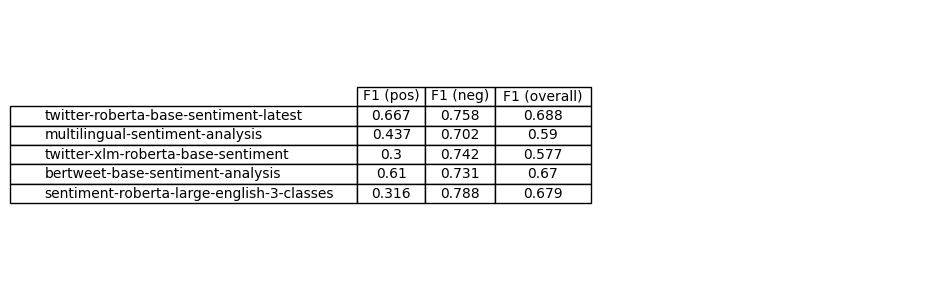

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

table = ax.table(
    cellText=results_df.values,
    rowLabels=results_df.index,
    colLabels=["F1 (pos)", "F1 (neg)", "F1 (overall)"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(results_df.columns))))
plt.tight_layout()
plt.show()